## Settings

In [60]:
## auto reload modules
%reload_ext autoreload
%autoreload 2

## Dependencies

In [61]:
## libraries
import sys
import pandas as pd
from pathlib import Path
from itertools import combinations

## path
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

## modules
from src.data.builders import load_processed_data
from src.estimators.factories.registry import load_estimators
from src.evaluators.training import fit_predict_frontier
from src.evaluators.metrics import consensus_metrics
from src.visualizers.visualizing import plot_consensus

## constants
from src.evaluators.metrics import CONSENSUS_METRICS
from src.evaluators.config import (
    FEAT_X,
    FEAT_Z,
    TARGET,
)

## Initialization

In [62]:
## reproducibility
N_DECIMALS = 2
N_REPEATS = 30
RANDOM_STATE = 42

## load data and models
data = load_processed_data()
models = load_estimators(random_state = RANDOM_STATE)

## view data shape
n_obs, n_feat = data.shape
print(f"Original Data: {n_feat} features, {n_obs} observations")

## view model surface
n_mods = len(models)
print(f"Learned Models: {n_mods} estimators")

Original Data: 32 features, 25 observations
Learned Models: 9 estimators


## Training

In [63]:
## train models
frontiers_current = globals().get("frontiers", dict())
if len(frontiers_current) != len(models):
    frontiers = dict()
    for name, model in models.items():
        print(f"Training {name}...")
        fit_result = fit_predict_frontier(
            data = data,
            feat_x = FEAT_X,
            feat_z = FEAT_Z,
            estimator_c = model.estimator_c,
            estimator_r = model.estimator_r,
            target = TARGET,
            n_repeat = N_REPEATS,
            random_state = RANDOM_STATE,
        )
        frontiers[name] = fit_result["y_pred"]
else:
    frontiers = frontiers_current

## compute pairwise consensus
results_list = list()
for (i, y_true), (j, y_pred) in combinations(iterable = frontiers.items(), r = 2):
    
    ## calculate all metrics
    metrics = consensus_metrics(y_true = y_true, y_pred = y_pred)
    results_list.append({
        "model_i": i,
        "model_j": j,
        **metrics,
    })

## Post-Processing

In [64]:
## convert to dataframe
results_data = pd.DataFrame(results_list)

## Model Consensus Evaluation
Pairwise agreement between fitted frontiers evaluates whether independently trained estimators converge on aligned capacity orderings. Each learner is fit 30 times on the full dataset, and predictions are averaged across repeats before agreement is computed across all model pairs.

- **Spearman (`ρ`)**: Global rank agreement between paired model frontiers.
- **Rank-Biased Overlap (`RBO`)**: Top-weighted agreement, emphasizing the high-capacity tail.
- **Distance Correlation (`DCR`)**: Nonlinear dependence between paired model frontiers.
- **Composite Index (`CI`)**: Geometric mean of agreement-scaled `ρ`, `RBO`, and `DCR`.

### Reporting Convention
Each model pair contributes one value per metric. The summary reports medians across all pairwise model comparisons. Prior to compounding, `ρ` is rescaled from `[-1, 1]` to `[0, 1]` so that negative rank agreement lowers `CI` without collapsing to a single floor. Pairwise comparisons are equally weighted. Higher values indicate stronger cross-model consensus.

In [ ]:
## preview results
round(number = results_data[CONSENSUS_METRICS].median(), ndigits = N_DECIMALS)

rho    0.96
rbo    0.90
dcr    0.96
ci     0.95
dtype: float64

_Pairwise estimator comparisons show consistently high cross-model consensus. Median global rank agreement reaches 0.96 (ρ) and nonlinear dependence alignment reaches 0.96 (DCR), with a Composite Index (CI) of 0.94 reflecting strong agreement across all dimensions simultaneously. Top-end overlap is also high at 0.90 (RBO), indicating that alignment extends to the high-capacity tail rather than being driven by mid-range agreement alone. Across methodologically distinct estimators, the recovered capacity ordering is stable and generally model-agnostic._

## Visualization

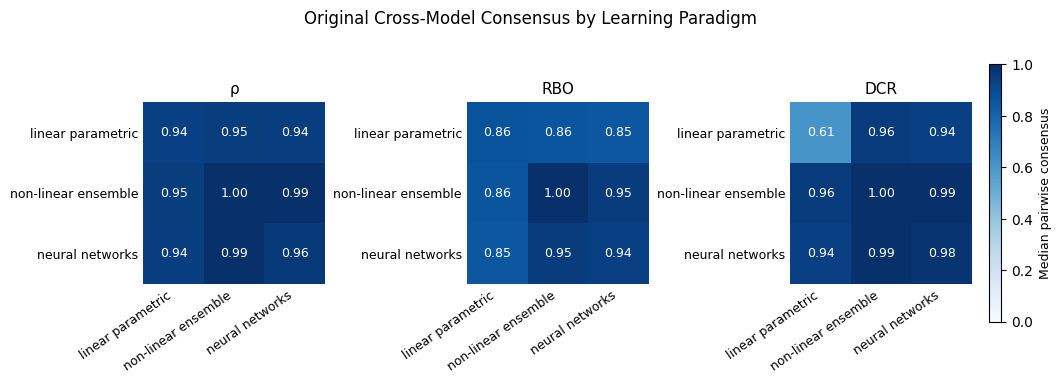

In [66]:
## paradigm-level consensus heatmaps
fig, ax, mat = plot_consensus(
    results = results_data,
    title = "Original Cross-Model Consensus by Learning Paradigm"
)